In [1]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [2]:


def build_weights(data, datadata, minvalue = -999, latlim = 90.):
    weights = datadata.isel(time = 0) > minvalue
    weights = weights *np.cos( np.deg2rad(data.lat))
    weights = weights*(abs(data.lat)<latlim)
    return weights

def anomaly(glbmean, weights, normalise = False, detrend = False):

    #nanoseconds per century required for fit
    ns_century = 1.e9*3600.*24.*365.*100.                # scaling: nono-seconds to century
    #detrend if desired
    if detrend:
        glbmean = glbmean.groupby('time.month').apply(detrend_monthly)

    
    databymth = glbmean.groupby("time.month")
    mthclim = databymth.mean("time")       # detrended climatological months (seasonal cycle)
    
    dataanom = databymth - mthclim          # detrended interannual annomaly
    if normalise:
        dataanom = dataanom/dataanom.std()
    dataanom = dataanom.rename('anom')   # change variable name
    return dataanom


def global_mean(data, datadata, weights):
    datadata_weighted = datadata.weighted(weights)
    weighted_mean = datadata_weighted.mean(('lat', 'lon'))
    return weighted_mean

def lat_bands_gt(data, datadata, minlat,maxlat, detrend = False):
    #select region
    data = data.sel(lat = slice(maxlat,minlat))
    datadata = datadata.sel(lat = slice(maxlat,minlat))
    #calculate anomaly
    data_weights = build_weights(data, datadata)
    data_glbmean = global_mean(data, datadata, data_weights)
    data_glbanom = anomaly(data_glbmean, data_weights, detrend = detrend)
    return data_glbanom


def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'months'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds




def detrend_monthly(group):
    ns_century = 1.e9*3600.*24.*365.*100.
    linfit = group.polyfit('time', 1)
    slope = linfit.polyfit_coefficients.isel(degree=0) * ns_century

    trend = xr.polyval(coord=group.time, coeffs=linfit.polyfit_coefficients)
    detrended_group = group - trend.values + group.mean(dim='time')

    return detrended_group





# Global Annual Temp


In [ ]:
#load dataset
fp = '/data/jmex/ERA5/monthly/era5_t2m.nc'
t2m = decode_time(fp)


#select rev. time only
t2m = t2m.sel(time = slice('1958-01-01', '2023-12-31'))

#compute the mean
t2m_weights = build_weights(t2m, t2m.t2m)
t2m_glbmean = global_mean(t2m, t2m.t2m, t2m_weights)

In [4]:
#compute the anomaly
t2m_glbanom = anomaly(t2m_glbmean, t2m_weights, detrend = False)

In [22]:
df = t2m_glbanom.to_dataframe(name = 'temperature_anomaly')
# Extract year and month from the time index
df['year'] = df.index.year
df['month'] = df.index.month

#
df['month_abbr'] = df['month'].apply(lambda x: calendar.month_abbr[x])


# Filter data for the year 2023
df_2023 = df[df['year'] == 2023]

# Filter data for the year 2023
df_2015 = df[df['year'] == 2015]

# Filter data for the year 1997
df_1997 = df[df['year'] == 1997]

# Filter data for the year 1982
df_1982 = df[df['year'] == 1982]


#filter out year 2023
df = df[df['year']!=2023]

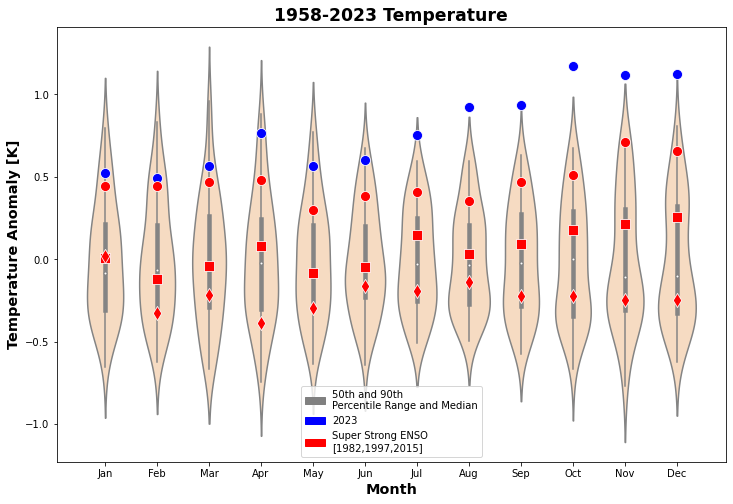

In [23]:
fig, ax = plt.subplots(figsize=(12, 8))

# Create a violin plot using seaborn
sns.violinplot(x='month_abbr', y='temperature_anomaly', data=df, 
               ax=ax, 
               inner_kws=dict(box_width=55, whis_width=2, color="1"),
               quantiles=[0.5, 0.9],
               order=calendar.month_abbr, color = 'peachpuff')

# Highlight points for the year 2023 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2023, color='b', s=100, ax=ax, zorder = 10)

# Highlight points for the year 2015 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2015, color='r', s=100, ax=ax, marker = 'o', zorder = 10)

# Highlight points for the year 1997 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1997, color='r', s=100, ax=ax, marker = 's', zorder = 10)


# Highlight points for the year 1982 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1982, color='r', s=100, ax=ax, marker = 'd', zorder = 10)


# Customize the plot
ax.set_title('1958-2023 Temperature')
ax.set_xlabel('Month')
ax.set_ylabel('Temperature Anomaly [K]')

# Create custom legend
median_patch = mpatches.Patch(color='grey', label='50th and 90th \nPercentile Range and Median')
l2023 = mpatches.Patch(color='b', label='2023')
lnino = mpatches.Patch(color='r', label='Super Strong ENSO \n[1982,1997,2015]')

ax.legend(handles=[median_patch, l2023, lnino], loc='lower center')
plt.savefig('/data/jmex/output/figures/poster/t2m.svg')
# Show the plot
plt.show()

# Global September Temp 

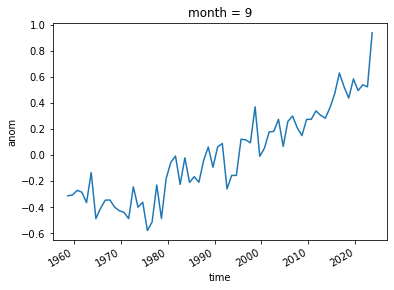

In [5]:
fp = '/data/jmex/ERA5/monthly/era5_t2m.nc'

t2m = decode_time(fp)
#select rev. time only
#select september only
t2m = t2m.sel(time = slice('1958-01-01', '2023-12-31'))
s2m = t2m.where(t2m.time.dt.month == 9, drop = True)


s2m_weights = build_weights(s2m, s2m.t2m)
s2m_glbmean = global_mean(s2m, s2m.t2m, s2m_weights)
s2m_glbanom = anomaly(s2m_glbmean, s2m_weights)

s2m_glbanom.plot()


# Sea Surfact Temp

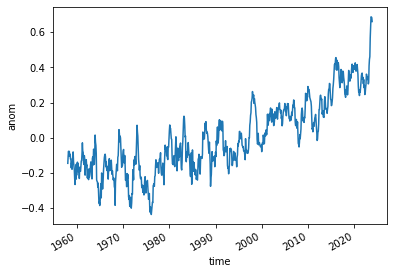

In [6]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp)#select rev. time only
#select revtime only
sst = sst.sel(time = slice('1958-01-01', '2023-12-31'))


sst_weights = build_weights(sst, sst.sst)
sst_glbmean = global_mean(sst, sst.sst, sst_weights)
sst_glbanom = anomaly(sst_glbmean, sst_weights)


sst_glbanom.plot()

# North Atlantic SST 

In [13]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp)

#define na_mask as  all of 1.NA SPSS, 2.NA STSS, 3.NA STPS
#after Fay and McKinley 2014
#see https://github.com/RECCAP2-ocean/R2-shared-resources/blob/master/data/regions/README.md

na_mask = masks.atlantic.isin([1,2,3])


In [14]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp)#select rev. time only
#select revtime only
#select box area
sst = sst.sel(time = slice('1958-01-01', '2023-12-31'))
na_sst = sst.where(na_mask)


na_sst_weights = build_weights(na_sst, na_sst.sst)
na_sst_glbmean = global_mean(na_sst, na_sst.sst, na_sst_weights)

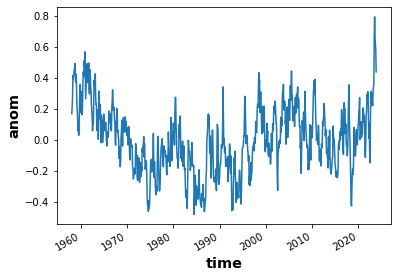

In [18]:
na_sst_glbanom = anomaly(na_sst_glbmean, na_sst_weights, detrend = True)


na_sst_glbanom.plot()

In [19]:
df = na_sst_glbanom.to_dataframe(name = 'temperature_anomaly')
# Extract year and month from the time index
df['year'] = df.index.year
df['month'] = df.index.month

#
df['month_abbr'] = df['month'].apply(lambda x: calendar.month_abbr[x])


# Filter data for the year 2023
df_2023 = df[df['year'] == 2023]

# Filter data for the year 2023
df_2015 = df[df['year'] == 2015]

# Filter data for the year 1997
df_1997 = df[df['year'] == 1997]

# Filter data for the year 1982
df_1982 = df[df['year'] == 1982]


#filter out year 2023
df = df[df['year']!=2023]

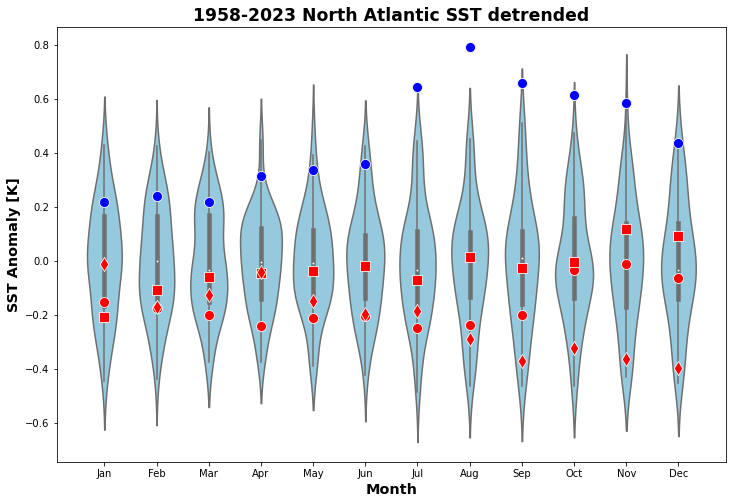

In [20]:
fig, ax = plt.subplots(figsize=(12, 8))

# Create a violin plot using seaborn
sns.violinplot(x='month_abbr', y='temperature_anomaly', data=df, 
               ax=ax, 
               inner_kws=dict(box_width=55, whis_width=2, color="1"),
               quantiles=[0.5, 0.9],
               order=calendar.month_abbr, color = 'skyblue')

# Highlight points for the year 2023 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2023, color='b', s=100, ax=ax, zorder = 10)

# Highlight points for the year 2015 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2015, color='r', s=100, ax=ax, marker = 'o', zorder = 10)

# Highlight points for the year 1997 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1997, color='r', s=100, ax=ax, marker = 's', zorder = 10)


# Highlight points for the year 1982 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1982, color='r', s=100, ax=ax, marker = 'd', zorder = 10)


# Customize the plot
ax.set_title('1958-2023 North Atlantic SST detrended')
ax.set_xlabel('Month')
ax.set_ylabel('SST Anomaly [K]')

# Create custom legend
median_patch = mpatches.Patch(color='k', label='50th and 90th \nPercentile Range and Median')
l2023 = mpatches.Patch(color='b', label='2023')
lnino = mpatches.Patch(color='r', label='Super Strong ENSO \n[1982,1997,2015]')

#ax.legend(handles=[median_patch, l2023, lnino], loc='lower center')
plt.savefig('/data/jmex/output/figures/poster/dt_nasst.svg')

# Show the plot
plt.show()

# Antarctic Sea Ice Normalised 

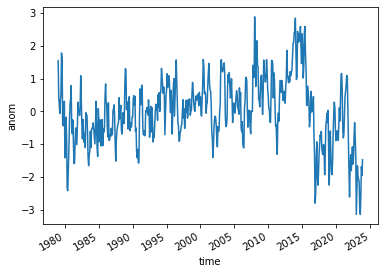

In [9]:
fp = '/data/jmex/ERA5/monthly/era5_ci.nc'

ci = decode_time(fp)

#select antarctic sea ice only
ci = ci.sel(time = slice('1979-01-01', '2023-12-31'))
ci = ci.where(ci.lat <0 )

ci_weights = build_weights(ci, ci.ci)
ci_glbmean = global_mean(ci, ci.ci, ci_weights)
ci_glbanom = anomaly(ci_glbmean, ci_weights, normalise = True)

ci_glbanom.plot()

ci_glbanom = encode_time(ci_glbanom, reference_time = '1979-01-01')
ci_glbanom.to_netcdf('/data/jmex/output/extremes/indicies/ci_anom.nc')

# Latitude Bands GT 

In [28]:

fp = '/data/jmex/ERA5/monthly/era5_t2m.nc'

t2m = decode_time(fp)
#select rev. time only
t2m = t2m.sel(time = slice('1958-01-01', '2023-12-31'))



t2m_glbanom_90S = lat_bands_gt(t2m, t2m.t2m, -90,-60)
t2m_glbanom_60S = lat_bands_gt(t2m, t2m.t2m, -60,-20)
t2m_glbanom_20S = lat_bands_gt(t2m, t2m.t2m, -20,20)
t2m_glbanom_20N = lat_bands_gt(t2m, t2m.t2m, 20,60)
t2m_glbanom_60N = lat_bands_gt(t2m, t2m.t2m, 60,90)



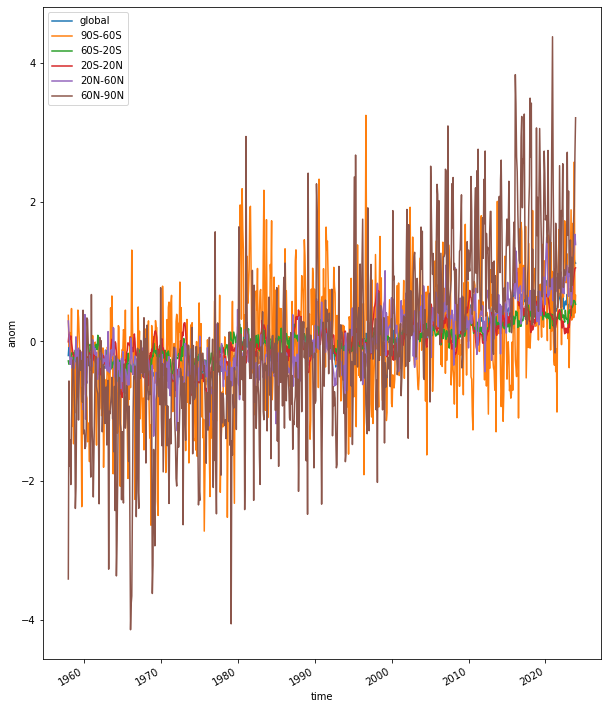

In [29]:
fig, ax = plt.subplots(1,1, figsize = (10,12))
t2m_glbanom.plot(ax = ax, label = 'global')
t2m_glbanom_90S.plot(ax = ax, label = '90S-60S')
t2m_glbanom_60S.plot(ax = ax, label = '60S-20S')
t2m_glbanom_20S.plot(ax = ax, label = '20S-20N')
t2m_glbanom_20N.plot(ax = ax, label = '20N-60N')
t2m_glbanom_60N.plot(ax = ax, label = '60N-90N')
plt.legend()


In [30]:
t2m_anom = xr.Dataset()
t2m_anom['global'] = t2m_glbanom
t2m_anom['S90-S60'] = t2m_glbanom_90S
t2m_anom['S60-S20'] = t2m_glbanom_60S
t2m_anom['S20-N20'] = t2m_glbanom_20S
t2m_anom['N20-N60'] = t2m_glbanom_20N
t2m_anom['N60-N90'] = t2m_glbanom_60S

t2m_anom = encode_time(t2m_anom)
t2m_anom.to_netcdf('/data/jmex/output/extremes/indicies/t2m_anom.nc')

# Latitude Bands GSST 

In [31]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'

sst = decode_time(fp)
#select rev. time only
sst = sst.sel(time = slice('1958-01-01', '2023-12-31'))



sst_glbanom_90S = lat_bands_gt(sst, sst.sst, -90,-60)
sst_glbanom_60S = lat_bands_gt(sst, sst.sst, -60,-20)
sst_glbanom_20S = lat_bands_gt(sst, sst.sst, -20,20)
sst_glbanom_20N = lat_bands_gt(sst, sst.sst, 20,60)
sst_glbanom_60N = lat_bands_gt(sst, sst.sst, 60,90)

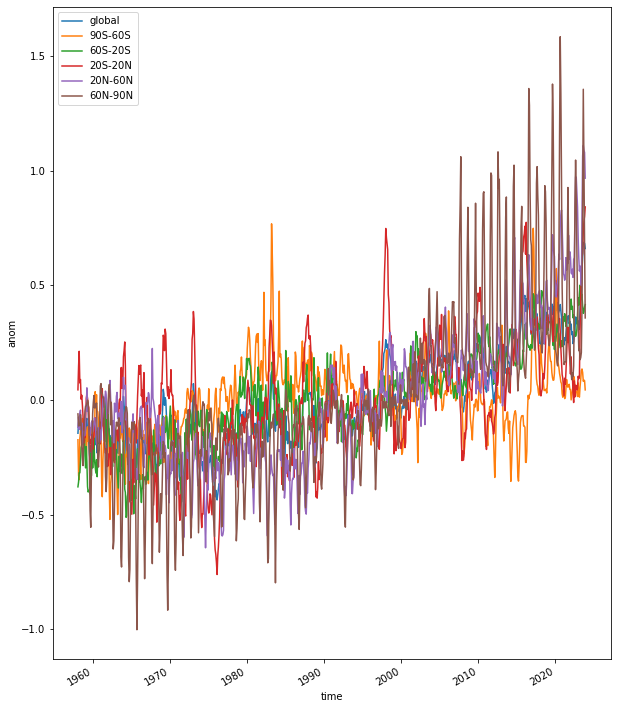

In [32]:
fig, ax = plt.subplots(1,1, figsize = (10,12))
sst_glbanom.plot(ax = ax, label = 'global')
sst_glbanom_90S.plot(ax = ax, label = '90S-60S')
sst_glbanom_60S.plot(ax = ax, label = '60S-20S')
sst_glbanom_20S.plot(ax = ax, label = '20S-20N')
sst_glbanom_20N.plot(ax = ax, label = '20N-60N')
sst_glbanom_60N.plot(ax = ax, label = '60N-90N')
plt.legend()

In [33]:
sst_anom = xr.Dataset()
sst_anom['global'] = sst_glbanom
sst_anom['S90-S60'] = sst_glbanom_90S
sst_anom['S60-S20'] = sst_glbanom_60S
sst_anom['S20-N20'] = sst_glbanom_20S
sst_anom['N20-N60'] = sst_glbanom_20N
sst_anom['N60-N90'] = sst_glbanom_60S
sst_anom['North_Atlantic'] = na_sst_glbanom

sst_anom = encode_time(sst_anom)
sst_anom.to_netcdf('/data/jmex/output/extremes/indicies/sst_anom.nc')

# GST Lat Bands

In [34]:
fp = '/data/jmex/ERA5/monthly/era5_t2m.nc'

t2m = decode_time(fp)
#select rev. time only
#select september only
t2m = t2m.sel(time = slice('1958-01-01', '2023-12-31'))
s2m = t2m.where(t2m.time.dt.month == 9, drop = True)



s2m_glbanom_90S = lat_bands_gt(s2m, s2m.t2m, -90,-60, detrend = True)
s2m_glbanom_60S = lat_bands_gt(s2m, s2m.t2m, -60,-20, detrend = True)
s2m_glbanom_20S = lat_bands_gt(s2m, s2m.t2m, -20,20, detrend = True)
s2m_glbanom_20N = lat_bands_gt(s2m, s2m.t2m, 20,60, detrend = True)
s2m_glbanom_60N = lat_bands_gt(s2m, s2m.t2m, 60,90, detrend = True)

In [48]:
s2m_anom = xr.Dataset()

s2m_anom['global'] = s2m_glbanom
s2m_anom['S90-S60'] = s2m_glbanom_90S
s2m_anom['S60-S20'] = s2m_glbanom_60S
s2m_anom['S20-N20'] = s2m_glbanom_20S
s2m_anom['N20-N60'] = s2m_glbanom_20N
s2m_anom['N60-N90'] = s2m_glbanom_60S


s2m_anom.attrs = {'units' : 'years'}
s2m_anom = encode_time(s2m_anom, reference_time = '1958-09-01', period = 'months' )
s2m_anom.to_netcdf('/data/jmex/output/extremes/indicies/s2m_anom.nc')

# Compute Indicies detrended (linear)

In [54]:
fp = '/data/jmex/ERA5/monthly/era5_t2m.nc'

t2m = decode_time(fp)
#select rev. time only
t2m = t2m.sel(time = slice('1958-01-01', '2023-12-31'))


t2m_glbanom = lat_bands_gt(t2m, t2m.t2m, -90,90, detrend = True)
#t2m_glbanom_90S = lat_bands_gt(t2m, t2m.t2m, -90,-60)
#t2m_glbanom_60S = lat_bands_gt(t2m, t2m.t2m, -60,-20)
#t2m_glbanom_20S = lat_bands_gt(t2m, t2m.t2m, -20,20)
#t2m_glbanom_20N = lat_bands_gt(t2m, t2m.t2m, 20,60)
#t2m_glbanom_60N = lat_bands_gt(t2m, t2m.t2m, 60,90)



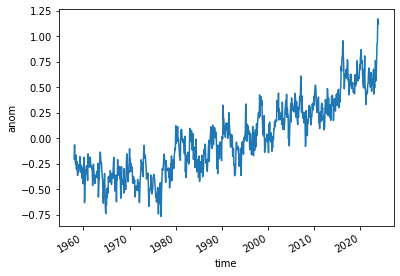

In [53]:
t2m_glbanom.plot()

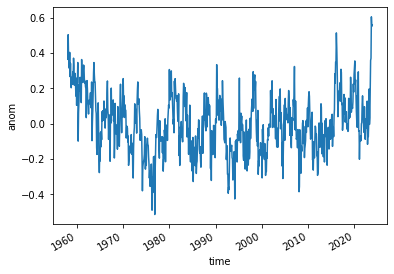

In [55]:
t2m_glbanom.plot()

In [5]:
t2m_anom = xr.Dataset()
t2m_anom['global'] = t2m_glbanom
t2m_anom['S90-S60'] = t2m_glbanom_90S
t2m_anom['S60-S20'] = t2m_glbanom_60S
t2m_anom['S20-N20'] = t2m_glbanom_20S
t2m_anom['N20-N60'] = t2m_glbanom_20N
t2m_anom['N60-N90'] = t2m_glbanom_60S

t2m_anom = encode_time(t2m_anom)
t2m_anom.to_netcdf('/data/jmex/output/extremes/indicies/t2m_anom_detrended.nc')

NameError: name 't2m_glbanom_90S' is not defined

# 500mb temperatures


In [4]:

fp = '/data/jmex/ERA5/monthly/era5_t500.nc'

t500 = decode_time(fp)
#select rev. time only
t500 = t500.sel(time = slice('1958-01-01', '2023-12-31'))


t500_glbanom = lat_bands_gt(t500, t500.t, -90,90)
t500_glbanom_90S = lat_bands_gt(t500, t500.t, -90,-60)
t500_glbanom_60S = lat_bands_gt(t500, t500.t, -60,-20)
t500_glbanom_20S = lat_bands_gt(t500, t500.t, -20,20)
t500_glbanom_20N = lat_bands_gt(t500, t500.t, 20,60)
t500_glbanom_60N = lat_bands_gt(t500, t500.t, 60,90)


In [5]:
t500_anom = xr.Dataset()
t500_anom['global'] = t500_glbanom
t500_anom['S90-S60'] = t500_glbanom_90S
t500_anom['S60-S20'] = t500_glbanom_60S
t500_anom['S20-N20'] = t500_glbanom_20S
t500_anom['N20-N60'] = t500_glbanom_20N
t500_anom['N60-N90'] = t500_glbanom_60S

t500_anom = encode_time(t500_anom)
t500_anom.to_netcdf('/data/jmex/output/extremes/indicies/t500_anom.nc')